In [1]:
import statsmodels.api as sm
import sys
sys.path.append("..")
from src.features.transforms import load_monthly
import warnings
warnings.filterwarnings("ignore")

m, r = load_monthly()
y = m["Price_Equipo1"]
X = sm.add_constant(m[["Price_Y"]])
ols1 = sm.OLS(y, X).fit()
print(ols1.summary())

                            OLS Regression Results                            
Dep. Variable:          Price_Equipo1   R-squared:                       0.998
Model:                            OLS   Adj. R-squared:                  0.998
Method:                 Least Squares   F-statistic:                 9.418e+04
Date:                Fri, 11 Sep 2026   Prob (F-statistic):          6.56e-226
Time:                        20:19:44   Log-Likelihood:                -485.62
No. Observations:                 164   AIC:                             975.2
Df Residuals:                     162   BIC:                             981.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          5.4863      1.526      3.595      0.0

p-value, menor a 0.05, y prueba t 307. ees estadísticamente significativa. R2, 99.8%, es exacta, dudaría, pero después de ver la gráfica la voy a aceptar. Su R2-ajustado igual.
durbin watson mayor a 2, autocorrelación positiva, los residuos impactan el comportamiento futuro. por eso se puede isar un sarimax para meter el residuo.

In [2]:
import statsmodels.api as sm
import sys
sys.path.append("..")
from src.features.transforms import load_monthly

m, r = load_monthly()
y = m["Price_Equipo2"]
X = sm.add_constant(m[["Price_Z"]])
ols1 = sm.OLS(y, X).fit()
print(ols1.summary())

                            OLS Regression Results                            
Dep. Variable:          Price_Equipo2   R-squared:                       0.975
Model:                            OLS   Adj. R-squared:                  0.975
Method:                 Least Squares   F-statistic:                     6303.
Date:                Fri, 11 Sep 2026   Prob (F-statistic):          1.31e-131
Time:                        20:30:32   Log-Likelihood:                -771.00
No. Observations:                 164   AIC:                             1546.
Df Residuals:                     162   BIC:                             1552.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -26.5308     11.733     -2.261      0.0

#### Grupos de dos

In [5]:
import pandas as pd
combos = {
    "Eq1 ~ Y":        ("Price_Equipo1", ["Price_Y"]),
    "Eq1 ~ Y + Z":    ("Price_Equipo1", ["Price_Y", "Price_Z"]),
    "Eq1 ~ Y + X":    ("Price_Equipo1", ["Price_Y", "Price_X"]),
    "Eq2 ~ Z":        ("Price_Equipo2", ["Price_Z"]),
    "Eq2 ~ Z + Y":    ("Price_Equipo2", ["Price_Z", "Price_Y"]),
    "Eq2 ~ Z + X":    ("Price_Equipo2", ["Price_Z", "Price_X"]),
}

filas = []
for nombre, (dep, indep) in combos.items():
    fit = sm.OLS(m[dep], sm.add_constant(m[indep])).fit()
    filas.append({
        "modelo": nombre,
        "R2_adj": round(fit.rsquared_adj, 4),
        "AIC": round(fit.aic, 1),
        **{f"p_{v}": round(fit.pvalues[v], 4) for v in indep},
    })

pd.DataFrame(filas)

,modelo,R2_adj,AIC,p_Price_Y,p_Price_Z,p_Price_X
0,Eq1 ~ Y,0.9983,975.2,0.0,NaN,NaN
1,Eq1 ~ Y + Z,0.9983,975.3,0.0,0.1741,NaN
2,Eq1 ~ Y + X,0.9997,664.9,0.0,NaN,0.0
3,Eq2 ~ Z,0.9748,1546.0,NaN,0.0000,NaN
4,Eq2 ~ Z + Y,0.9979,1141.7,0.0,0.0000,NaN
5,Eq2 ~ Z + X,0.9798,1510.7,NaN,0.0000,0.0


Sorpresa, en eq1 el X es estadisticamente significativo. en eq2, como se vio antes, el Y también.

#### Todos a la vez

In [7]:
for dep in ["Price_Equipo1", "Price_Equipo2"]:
    fit = sm.OLS(m[dep], sm.add_constant(m[["Price_X", "Price_Y", "Price_Z"]])).fit()
    print(dep)
    print(fit.summary().tables[1])

Price_Equipo1
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0353      0.829      0.043      0.966      -1.601       1.672
Price_X        0.1983      0.007     30.038      0.000       0.185       0.211
Price_Y        0.8006      0.002    395.558      0.000       0.797       0.805
Price_Z       -0.0001      0.001     -0.147      0.884      -0.002       0.001
Price_Equipo2
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.6357      1.224      0.519      0.604      -1.781       3.053
Price_X        0.3353      0.010     34.387      0.000       0.316       0.355
Price_Y        0.3353      0.003    112.156      0.000       0.329       0.341
Price_Z        0.3322      0.001    301.506      0.000       0.330       0.334


se ve que el equipo2 es el promedio simple de las 3 materias primas.

In [9]:
m["Price_Equipo1"] - (0.2*m["Price_X"] + 0.8*m["Price_Y"])

Date
2010-01-31   -1.184600
2010-02-28   -1.214500
2010-03-31   -0.285391
2010-04-30   -1.411238
2010-05-31   -0.330476
                ...   
2023-04-30    3.619684
2023-05-31    1.854609
2023-06-30    1.559455
2023-07-31    1.354286
2023-08-31   -1.028783
Freq: ME, Length: 164, dtype: float64

In [10]:
res1 = m["Price_Equipo1"] - (0.2*m["Price_X"] + 0.8*m["Price_Y"])
res2 = m["Price_Equipo2"] - (m["Price_X"] + m["Price_Y"] + m["Price_Z"])/3

for n, res, base in [("Eq1", res1, m["Price_Equipo1"]), ("Eq2", res2, m["Price_Equipo2"])]:
    print(n, "media", round(res.mean(), 3), "std", round(res.std(), 3),
          "MAPE", f"{(res.abs()/base).mean():.3%}")

Eq1 media -0.004 std 1.81 MAPE 0.304%
Eq2 media -0.373 std 2.681 MAPE 0.245%


Media es 0, las fórmulas son exactas:
 * Equipo 1 = 0.2·X + 0.8·Y
* Equipo 2 = (X + Y + Z) / 3

Recorrimos el camino correlación+cointegración+regresión lineal. descubrimos que es combinación lineal de los precios. Entoncse ya no hay que hacer series de tiempo con exógenas.
Todo el trabajo se mueve al pronóstico de X,Y y Z.

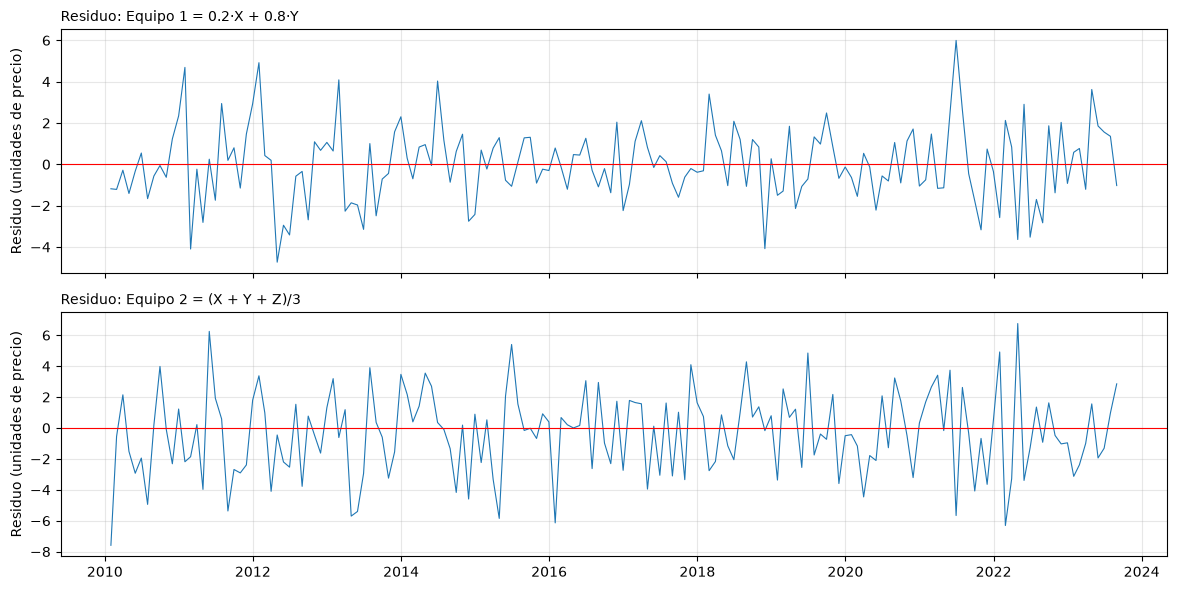

In [11]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
for ax, (nombre, res) in zip(axes, [("Equipo 1 = 0.2·X + 0.8·Y", res1),
                                     ("Equipo 2 = (X + Y + Z)/3", res2)]):
    ax.plot(res.index, res, linewidth=0.8)
    ax.axhline(0, color="red", linewidth=0.8)
    ax.set_title(f"Residuo: {nombre}", loc="left", fontsize=10)
    ax.set_ylabel("Residuo (unidades de precio)")
    ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig("../reports/figures/residuos_formulas.png", dpi=150, bbox_inches="tight")

Ruido blanco en ambos: oscilan alrededor de cero, sin tendencia, sin cambio de varianza, sin patrón estacional. Exactamente lo que confirma que las fórmulas son la relación real y no una aproximación